# Worldmap Temperature Anomaly Plots

## Origin of Files

In [43]:
#Short history of commands and origin of files:
# The commands are for the PI dataset, the other datasets have been created exactly analogous 
# just the names of the files have been exchanged, they can be found in the folders
# /data/modeldata/ICON/icon-paleo/LIG.kepler/remapped_r2b4  &  ./data/modeldata/ICON/icon-paleo/LIG.kepler.ghg/remapped_r2b4

#
#Merging:
#        cdo mergetime ../PI.kepler.mk_atm_2d_ml_*.nc PI.kepler_atm2d_merged.nc
#
#Regridding:
#        getting gridfiles/icon_grid_0012_R02B04_G.nc
#                ==> downloaded original from ICON paleo website, is the gridfile for R02B04 grid
#        creating gridfiles/target_grid_1_5.txt
#                ==> got from Kiras 0.75 grid, changed numbers pretty self explanatory!
#
#        Creating weightfile in gridfiles:
#        cdo gendis,gridfiles/target_grid_1_5.txt -setgrid,gridfiles/icon_grid_0012_R02B04_G.nc  PI.kepler_atm2d_merged.nc gridfiles/weightfile_R02B04_to_1_5_deg
#
#        Actual Remapping:
#        cdo -remap,gridfiles/target_grid_1_5.txt,gridfiles/weightfile_R02B04_to_1_5_deg PI.kepler_atm2d_merged.nc PI.kepler_atm2d_merged_remapped.nc
#
#Selecting the relevant years:
#        cdo selyear,1770/1800 PI.kepler_atm2d_merged_remapped.nc PI.kepler_atm2d_merged_remapped_1770_1800.nc
#
#
#Extracting DIFFERENT data:
#
#        Creating Means:
#        cdo ymonmean PI.kepler_atm2d_merged_remapped_1770_1800.nc ymonmean_PI.kepler_atm2d_merged_remapped_1770_1800.nc
#



## Basic Import Statements

In [44]:
# %%
import xarray as xr
import numpy as np
#from scipy.stats import pearsonr
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
#from tqdm import tqdm
import os
import socket
import psutil
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Loading rcParams

In [45]:
import importlib
import plot_settings
importlib.reload(plot_settings)
plot_settings.load_rcParams()

## Loading Data (ymonmeans)

In [46]:
def determine_system() -> str:
    many_cores  = os.cpu_count() > 16
    lots_of_ram = psutil.virtual_memory().total > 64 * 1024**3  # more than 64 GB
    if many_cores and lots_of_ram:
        return 'Cluster'
    else:
        return 'Jakob_Laptop'

if determine_system() == 'Jakob_Laptop':
    location_of_data = '../'
else:
    location_of_data = '/data/modeldata/ICON/icon-paleo/'

print('Loading ymonmean Data')
PI      = xr.open_dataset(location_of_data + 'PI.kepler/remapped_r2b4/ymonmean_PI.kepler_atm2d_merged_remapped_1770_1800.nc')
LIG     = xr.open_dataset(location_of_data + 'LIG.kepler/remapped_r2b4/ymonmean_LIG.kepler_atm2d_merged_remapped_1770_1800.nc')
LIG_ghg = xr.open_dataset(location_of_data + 'LIG.kepler.ghg/remapped_r2b4/ymonmean_LIG.kepler.ghg_atm2d_merged_remapped_1770_1800.nc')



#PI  = xr.open_dataset('../PI.kepler/remapped_r2b4/ymonmean_PI.kepler_atm2d_merged_remapped_1770_1800.nc')
#LIG  = xr.open_dataset('../LIG.kepler/remapped_r2b4/ymonmean_LIG.kepler_atm2d_merged_remapped_1770_1800.nc')
#LIG_ghg = xr.open_dataset('../LIG.kepler.ghg/remapped_r2b4/ymonmean_LIG.kepler.ghg_atm2d_merged_remapped_1770_1800.nc')


Loading ymonmean Data


## Deriving Worldmap Anomalies

In [47]:
#extract Juli
def extract_month(PI: xr.DataArray, month: int = 7) -> xr.DataArray:
    PI_mon = PI.sel(time=PI.time.dt.month == month)
    return PI_mon

def remove_useless_dims(ds):
    if 'height_2' in PI.dims:
        ds = ds.squeeze('height_2')
    if 'height' in PI.dims:
        ds = ds.squeeze('height')
    return ds

def get_annual_mean(ds):
    #takes annual mean only for ymonmean data!
    return ds.mean(dim='time')

PI,LIG,LIG_ghg = [remove_useless_dims(ds) for ds in [PI,LIG,LIG_ghg]]


PI_Jul      = extract_month(PI,      month =7)
LIG_Jul     = extract_month(LIG,     month =7)
LIG_ghg_Jul = extract_month(LIG_ghg, month =7)

PI_Jan      = extract_month(PI,      month =1)
LIG_Jan     = extract_month(LIG,     month =1)
LIG_ghg_Jan = extract_month(LIG_ghg, month =1)

PI_ann,LIG_ann,LIG_ghg_ann = [get_annual_mean(ds) for ds in [PI,LIG,LIG_ghg]] #ann stands for annual not Anomaly




# derive anomaly
Anom_Jul_LIG_PI = LIG_Jul - PI_Jul
Anom_Jan_LIG_PI = LIG_Jan - PI_Jan
Anom_ann_LIG_PI = LIG_ann - PI_ann



## Plotting Annual, Juli and January Mean

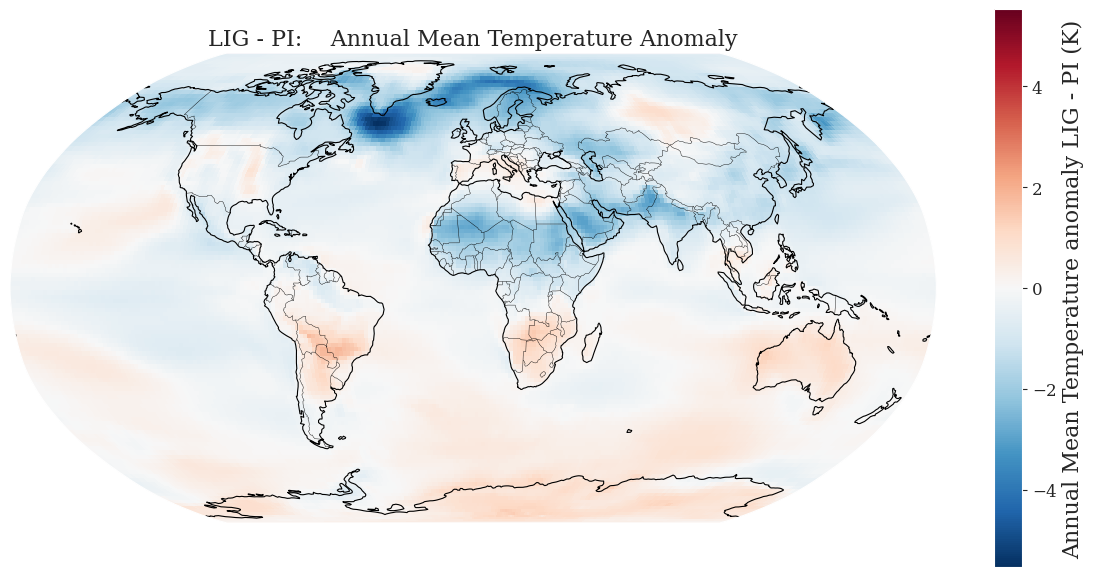

In [48]:


fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.Robinson()}  # Robinson = the classic oval worldmap
)

Anom_ann_LIG_PI.t_2m.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),  # tells cartopy your data is in regular lon/lat
    cmap="RdBu_r",
    cbar_kwargs={"label": "Annual Mean Temperature anomaly LIG - PI (K)"}
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)  # optional

plt.title("LIG - PI:    Annual Mean Temperature Anomaly")
plt.tight_layout()
plt.savefig('figs/LIG-PI_Annual_Temperature_Anomaly')


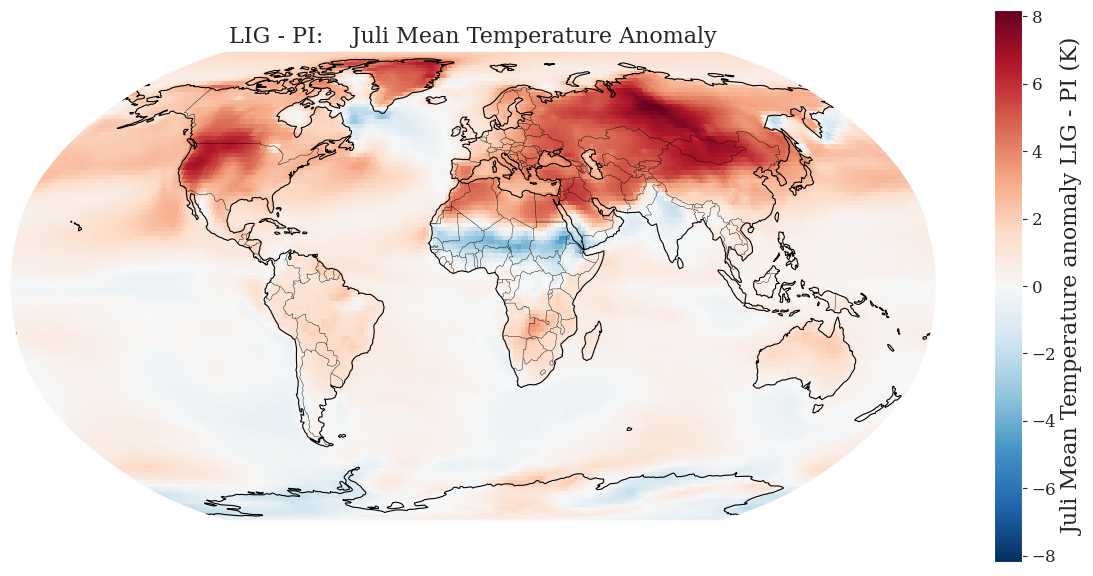

In [49]:
fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.Robinson()}  # Robinson = the classic oval worldmap
)

Anom_Jul_LIG_PI.t_2m.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),  # tells cartopy your data is in regular lon/lat
    cmap="RdBu_r",
    cbar_kwargs={"label": "Juli Mean Temperature anomaly LIG - PI (K)"}
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)  # optional

plt.title("LIG - PI:    Juli Mean Temperature Anomaly")
plt.tight_layout()
plt.savefig('figs/LIG-PI_Juli_Temperature_Anomaly')

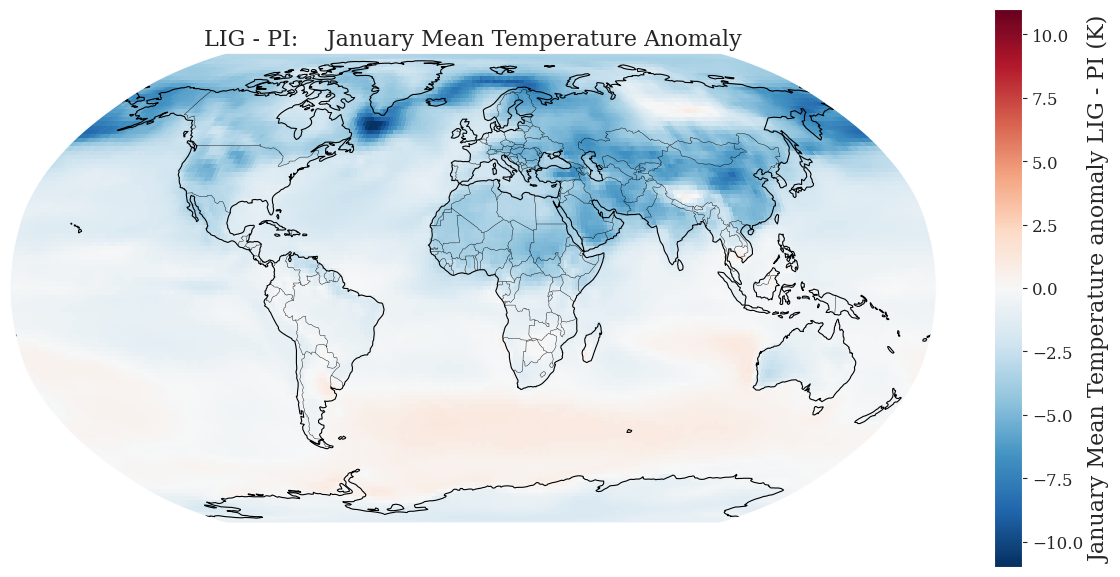

In [50]:
fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.Robinson()}  # Robinson = the classic oval worldmap
)

Anom_Jan_LIG_PI.t_2m.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),  # tells cartopy your data is in regular lon/lat
    cmap="RdBu_r",
    cbar_kwargs={"label": "January Mean Temperature anomaly LIG - PI (K)"}
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)  # optional

plt.title("LIG - PI:    January Mean Temperature Anomaly")
plt.tight_layout()
plt.savefig('figs/LIG-PI_January_Temperature_Anomaly')